In [1]:
import fiftyone as fo
import fiftyone.utils.yolo as fouy
from fiftyone import ViewField as F
import fiftyone.brain as fob
import fiftyone.zoo as foz
import fiftyone.core.utils as fou
import fiftyone.utils.yolo as fouy

In [2]:
from pathlib import Path
from tqdm import tqdm
from glob import glob
import os

from PIL import Image
import cv2
import numpy as np

import torch
from torch.utils.data import Dataset
from torchvision import transforms

In [3]:
from tqdm.notebook import tqdm

In [4]:
fo.list_datasets()

['2test_video_dataset',
 'landmarks',
 'local_video_test',
 'local_video_test2',
 'local_video_test3',
 'local_video_test5',
 'local_video_test6',
 'utkface']

In [5]:
pwd

'c:\\Users\\anspa\\au10tix\\face_classification'

In [6]:
ds_path = 'UTKFace'
dataset_dir = Path(ds_path)

In [11]:
files = os.listdir(ds_path)
imgs = [f for f in files if f.endswith(('.jpg', '.png'))]
print(len(imgs))

23708


# Utils

In [5]:
RACE_MAP = {
    0: "white",
    1: "black",
    2: "asian",
    3: "indian",
    4: "other",
}

GENDER_MAP = {
    0: "male",
    1: "female",
}

In [6]:
def parse_utkface_filename(filename: str):
    """
    Parses UTKFace filename and extracts age, gender, race.
    
    Expected format:
    [age]_[gender]_[race]_[timestamp].jpg
    
    Returns:
        dict or None if parsing fails
    """
    name = Path(filename).name

    # Remove extensions like .chip.jpg or .jpg
    name = name.split(".")[0]

    parts = name.split("_")

    if len(parts) < 3:
        return None

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])

        return {
            "age": age,
            "gender": gender,
            "gender_str": GENDER_MAP.get(gender, "unknown"),
            "race": race,
            "race_str": RACE_MAP.get(race, "unknown"),
        }

    except ValueError:
        return None


In [7]:
def load_utkface_to_fiftyone(dataset_dir: str, dataset_name: str) -> fo.Dataset:
    """
    Loads UTKFace dataset into FiftyOne.

    Args:
        dataset_dir: path to UTKFace images
        dataset_name: name of FiftyOne dataset

    Returns:
        fo.Dataset
    """
    dataset = fo.Dataset(dataset_name, persistent=True)

    image_paths = list(Path(dataset_dir).glob("*"))

    samples = []

    for img_path in image_paths:
        parsed = parse_utkface_filename(img_path.name)

        if parsed is None:
            continue  # skip bad filenames

        sample = fo.Sample(filepath=str(img_path))

        # Add attributes
        sample["age"] = parsed["age"]
        sample["gender"] = parsed["gender_str"]
        sample["race"] = parsed["race_str"]

        samples.append(sample)

    dataset.add_samples(samples)

    print(f"Loaded {len(samples)} samples into dataset '{dataset_name}'")

    return dataset

## Face Detection Utils

In [8]:
from mtcnn import MTCNN

def load_mtcnn(device="CPU:0"):
    return MTCNN(device=device)

In [9]:
def detect_faces_mtcnn(image_path, detector):
    image = Image.open(image_path).convert("RGB")
    image = np.asarray(image)

    results = detector.detect_faces(image)

    boxes = []
    confidences = []
    keypoints = []

    for r in results:
        boxes.append(r["box"])              # [x, y, w, h]
        confidences.append(r["confidence"])
        keypoints.append(r.get("keypoints"))

    return boxes, confidences, keypoints

In [10]:
def get_face_detection_issue(boxes, confidences, conf_thresh=0.90):
    valid_indices = [
        i for i, conf in enumerate(confidences)
        if conf >= conf_thresh
    ]

    if len(valid_indices) == 0:
        return "no_confident_face_detected"

    if len(valid_indices) > 1:
        return "multiple_faces_detected"

    return "ok"

In [11]:
def mark_mtcnn_face_issues_in_fiftyone(
    dataset,
    detector,
    issue_field="face_issue",
    num_faces_field="num_detected_faces",
    conf_thresh=0.90,
):
    for sample in tqdm(dataset, total=len(dataset), desc="Running MTCNN"):
        boxes, confidences, keypoints = detect_faces_mtcnn(
            sample.filepath,
            detector,
        )

        issue = get_face_detection_issue(
            boxes,
            confidences,
            conf_thresh=conf_thresh,
        )

        # These fields are overwritten if they already exist
        sample[issue_field] = issue
        sample[num_faces_field] = len(boxes)
        sample["mtcnn_confidences"] = [float(c) for c in confidences]
        sample["mtcnn_boxes_xywh"] = [
            [float(v) for v in box] for box in boxes
        ]

        sample.save()

    print("Done. Existing values were overwritten.")

# Load and Explore

In [7]:
# dataset = load_utkface_to_fiftyone(ds_path, "utkface")
# dataset.persistent = True
dataset = fo.load_dataset("utkface")


In [20]:
dataset.compute_metadata()

Computing metadata...
 100% |█████████████| 23708/23708 [46.3s elapsed, 0s remaining, 833.3 samples/s]      


In [17]:
session = fo.launch_app(
    dataset,
    port=5151,
    address="127.0.0.1",
)

In [14]:
import lz4
from mtcnn import MTCNN

# Data Cleaning

In [26]:
for sample in tqdm(dataset):
    sample["file_hash"] = fou.compute_filehash(sample.filepath)
    sample.save()

print(dataset)

100%|██████████| 23708/23708 [01:13<00:00, 324.09it/s]

Name:        utkface
Media type:  image
Num samples: 23708
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    age:              fiftyone.core.fields.IntField
    gender:           fiftyone.core.fields.StringField
    race:             fiftyone.core.fields.StringField
    file_hash:        fiftyone.core.fields.IntField


In [27]:
from collections import Counter

filehash_counts = Counter(sample.file_hash for sample in dataset)
dup_filehashes = [k for k, v in filehash_counts.items() if v > 1]

print("Number of duplicate file hashes: %d" % len(dup_filehashes))

Number of duplicate file hashes: 375


In [28]:
dup_filehashes

[-4582114799487776407,
 -4339230940409287630,
 -6875002819227014053,
 269955760431561298,
 -2787261890045019780,
 4666489648741143823,
 5860672343561587956,
 -444896959289398973,
 7147117529983176015,
 5744580120147147840,
 -2415889620599628466,
 5568481832567459663,
 -3006860566948194120,
 -8000512708724676246,
 2450590993217306441,
 8006691396548447038,
 8093444165063664961,
 -2923968807763519846,
 -8187637621954379207,
 -8005984854014038111,
 -3091988371216742612,
 961557584417942911,
 2228382963848868744,
 -9003372217379829872,
 6922483602311322928,
 -8792769041443850716,
 -6993768168120350031,
 -5732523185980952493,
 34054773817103214,
 7926641851754398763,
 5874159284822736188,
 8204226665795332705,
 -3122070386188041203,
 -602366145371051219,
 -2407871231785475117,
 5953082374463441685,
 -2735186380086980329,
 8032001416747146696,
 -6521473266613360530,
 -3617288783873677145,
 -3748636691328769982,
 -2481501290989050099,
 -2931437248153525056,
 -8520001144316676974,
 -6259955183

In [29]:
dup_view = (dataset
    # Extract samples with duplicate file hashes
    .match(F("file_hash").is_in(dup_filehashes))
    # Sort by file hash so duplicates will be adjacent
    .sort_by("file_hash")
)

print("Number of images that have a duplicate: %d" % len(dup_view))
print("Number of duplicates: %d" % (len(dup_view) - len(dup_filehashes)))

Number of images that have a duplicate: 765
Number of duplicates: 390


In [30]:
dup_view

Dataset:     utkface
Media type:  image
Num samples: 765
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    age:              fiftyone.core.fields.IntField
    gender:           fiftyone.core.fields.StringField
    race:             fiftyone.core.fields.StringField
    file_hash:        fiftyone.core.fields.IntField
View stages:
    1. Match(filter={'$expr': {'$in': [...]}})
    2. SortBy(field_or_expr='file_hash', reverse=False, create_index=True)

In [32]:
# dup_ids = []
for sample in dup_view:
#     dup_ids.append(sample.id)
    sample['tags'].append('has_dupp')
    sample.save()

In [ ]:
dups_view = dataset.match_tags("has_dupp").sort_by("file_hash")
session.view = dups_view

In [34]:
first_elements = []
first_elements_ids = []
other_elements = []
other_elements_ids = []

for sample in dups_view:
    # print(sample.id)
    # print(sample.file_hash)

    if sample.file_hash not in first_elements:
        first_elements.append(sample.file_hash)
        first_elements_ids.append(sample.id)
        
    else:
        other_elements.append(sample.file_hash)
        other_elements_ids.append(sample.id)
        
print(len(first_elements))
print(len(other_elements))

375
390


In [35]:
dataset.delete_samples(other_elements_ids)

## Uniqueness 

In [36]:
fob.compute_uniqueness(dataset)

 100% |████|  100.6Mb/100.6Mb [4.2s elapsed, 0s remaining, 31.8Mb/s]      
Computing embeddings...
 100% |█████████████| 23318/23318 [1.4m elapsed, 0s remaining, 329.5 samples/s]      
Computing uniqueness...
Generating neighbors graph for 23318 embeddings...
Index complete


c:\Users\anspa\miniconda3\envs\acho\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\anspa\miniconda3\envs\acho\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\anspa\miniconda3\envs\acho\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\anspa\miniconda3\envs\acho\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\anspa\miniconda3\envs\acho\Lib\subprocess.py", line 1538, in 

Uniqueness computation complete


In [39]:
low_uniqueness = dataset.match(F("uniqueness") < 0.2).sort_by("uniqueness", reverse=False)
# rank_view = dataset.sort_by("uniqueness", reverse=True)

In [41]:
len(low_uniqueness)

204


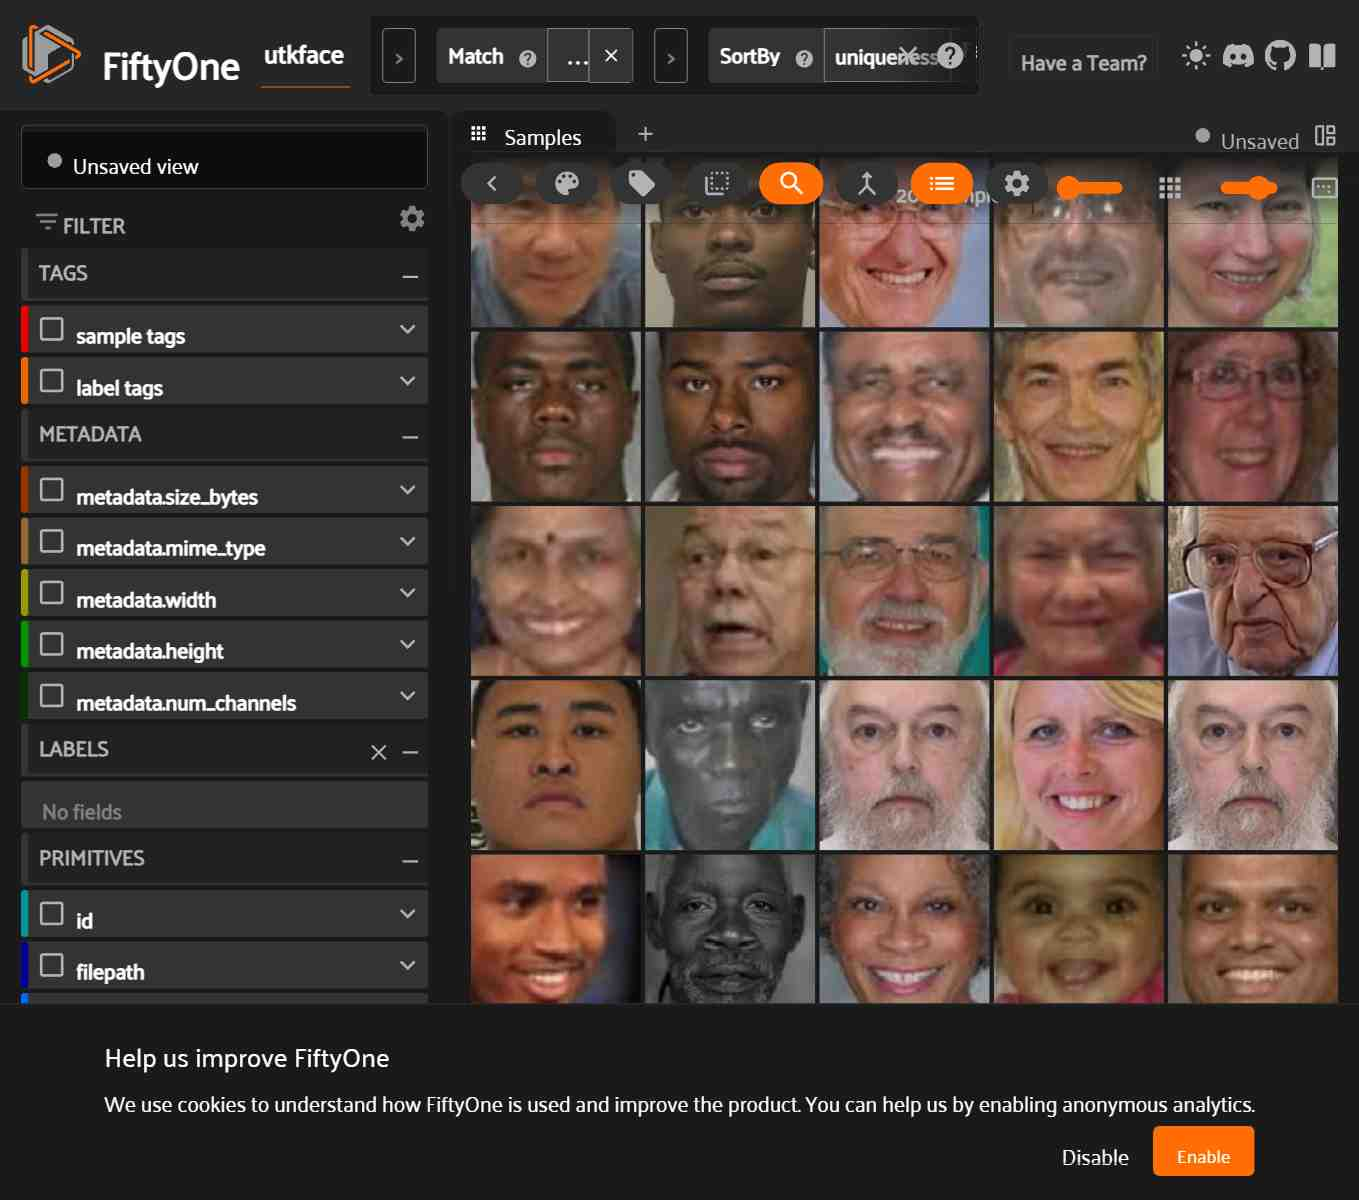

In [40]:
session.view = low_uniqueness

In [42]:
fob.compute_similarity(
    dataset, model="clip-vit-base32-torch", brain_key="clip")

 100% |██████|    2.6Gb/2.6Gb [58.0s elapsed, 0s remaining, 42.3Mb/s]      
 100% |█████|   10.4Mb/10.4Mb [3.2s elapsed, 0s remaining, 3.6Mb/s]      
Computing embeddings...
 100% |█████████████| 23318/23318 [12.7m elapsed, 0s remaining, 32.8 samples/s]      


In [43]:
image_index = dataset.load_brain_results("clip")

In [44]:
list_samples_with_emb = image_index.sample_ids.tolist()
all_embeddings_view = dataset.select(list_samples_with_emb)
all_clip_embeddings = image_index.embeddings

In [47]:
# Compute visualization
vis_results_clip = fob.compute_visualization(
    all_embeddings_view, method='tsne', embeddings=all_clip_embeddings, seed=51, brain_key="clip_viz"
)

Generating visualization...


c:\Users\anspa\miniconda3\envs\acho\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 23318 samples in 0.003s...
[t-SNE] Computed neighbors for 23318 samples in 1.203s...
[t-SNE] Computed conditional probabilities for sample 1000 / 23318
[t-SNE] Computed conditional probabilities for sample 2000 / 23318
[t-SNE] Computed conditional probabilities for sample 3000 / 23318
[t-SNE] Computed conditional probabilities for sample 4000 / 23318
[t-SNE] Computed conditional probabilities for sample 5000 / 23318
[t-SNE] Computed conditional probabilities for sample 6000 / 23318
[t-SNE] Computed conditional probabilities for sample 7000 / 23318
[t-SNE] Computed conditional probabilities for sample 8000 / 23318
[t-SNE] Computed conditional probabilities for sample 9000 / 23318
[t-SNE] Computed conditional probabilities for sample 10000 / 23318
[t-SNE] Computed conditional probabilities for sample 11000 / 23318
[t-SNE] Computed conditional probabilities for sample 12000 / 23318
[t-SNE] Computed conditional probabilities for sam

## Face Detected

In [15]:
detector = load_mtcnn(device="GPU:0")

In [16]:
mark_mtcnn_face_issues_in_fiftyone(
    dataset,
    detector,
    conf_thresh=0.90,
)

Running MTCNN:   0%|          | 0/23318 [00:00<?, ?it/s]

AutoReconnect: localhost:62292: [WinError 10054] An existing connection was forcibly closed by the remote host (configured timeouts: connectTimeoutMS: 20000.0ms)


# Dataset Creation

## Utils

In [19]:
import random

def stratified_race_split_tags(
    dataset,
    race_field="race",
    split_tags=("train", "validation", "test"),
    fractions=(0.70, 0.15, 0.15),
    seed=42,
    race_categories=None,
    clear_existing=True,
):
    """
    Stratified 70/15/15 split by race.

    Adds exactly one split tag to each sample:
    - train
    - validation
    - test
    """

    assert len(split_tags) == 3
    assert len(fractions) == 3
    assert abs(sum(fractions) - 1.0) < 1e-6

    if race_categories is None:
        race_categories = sorted(dataset.distinct(race_field))

    total_samples = len(dataset)

    if clear_existing:
        for sample in tqdm(dataset, total=total_samples, desc="Clearing old split tags"):
            sample.tags = [tag for tag in sample.tags if tag not in split_tags]
            sample.save()

    rng = random.Random(seed)

    split_counts = {
        race: {tag: 0 for tag in split_tags}
        for race in race_categories
    }

    for race in tqdm(race_categories, desc="Splitting race categories"):
        view = dataset.match(F(race_field) == race)
        sample_ids = list(view.values("id"))

        rng.shuffle(sample_ids)

        n = len(sample_ids)
        n_train = int(n * fractions[0])
        n_val = int(n * fractions[1])

        split_id_groups = {
            split_tags[0]: sample_ids[:n_train],
            split_tags[1]: sample_ids[n_train:n_train + n_val],
            split_tags[2]: sample_ids[n_train + n_val:],
        }

        for split_tag, ids in split_id_groups.items():
            samples = dataset.select(ids)

            for sample in tqdm(
                samples,
                total=len(ids),
                desc=f"Tagging {race} / {split_tag}",
                leave=False,
            ):
                sample.tags.append(split_tag)
                sample.save()

            split_counts[race][split_tag] = len(ids)

    return split_counts

In [20]:
split_counts = stratified_race_split_tags(
    dataset,
    race_categories=["white", "black", "asian", "indian", "other"],
    seed=42,
)

split_counts


Clearing old split tags:   0%|          | 0/23318 [00:00<?, ?it/s]

Splitting race categories:   0%|          | 0/5 [00:00<?, ?it/s]

Tagging white / train:   0%|          | 0/6967 [00:00<?, ?it/s]

Tagging white / validation:   0%|          | 0/1493 [00:00<?, ?it/s]

Tagging white / test:   0%|          | 0/1494 [00:00<?, ?it/s]

...

Tagging indian / test:   0%|          | 0/584 [00:00<?, ?it/s]

Tagging other / train:   0%|          | 0/1146 [00:00<?, ?it/s]

Tagging other / validation:   0%|          | 0/245 [00:00<?, ?it/s]

Tagging other / test:   0%|          | 0/247 [00:00<?, ?it/s]

{'white': {'train': 6967, 'validation': 1493, 'test': 1494},
 'black': {'train': 3114, 'validation': 667, 'test': 668},
 'asian': {'train': 2370, 'validation': 508, 'test': 509},
 'indian': {'train': 2720, 'validation': 583, 'test': 584},
 'other': {'train': 1146, 'validation': 245, 'test': 247}}

In [22]:
train_view = dataset.match_tags("train")
validation_view = dataset.match_tags("validation")
test_view = dataset.match_tags("test")

print(len(train_view), len(validation_view), len(test_view))




16317 3496 3502


In [23]:
print("Train:", train_view.count_values("race"))
print("Validation:", validation_view.count_values("race"))
print("Test:", test_view.count_values("race"))


Train: {'white': 6967, 'indian': 2720, 'black': 3114, 'asian': 2370, 'other': 1146}
Validation: {'asian': 508, 'other': 245, 'white': 1493, 'indian': 583, 'black': 667}
Test: {'white': 1494, 'other': 247, 'indian': 584, 'black': 668, 'asian': 509}


In [44]:
import re
import pandas as pd
from pathlib import Path


GENDER_TO_ID = {
    "male": 0,
    "female": 1,
}

RACE_TO_ID = {
    "white": 0,
    "black": 1,
    "asian": 2,
    "indian": 3,
    "other": 4,
}

SPLIT_TO_ID = {
    "train": 0,
    "validation": 1,
    "val": 1,
    "test": 2,
}


def versioned_csv_path(output_csv, version):
    output_csv = Path(output_csv)

    if output_csv.suffix.lower() != ".csv":
        output_csv = output_csv.with_suffix(".csv")

    base_stem = re.sub(
        r"[_-]v(?:ersion)?[_-]?[0-9]+(?:\.[0-9]+)*$",
        "",
        output_csv.stem,
        flags=re.IGNORECASE,
    )

    return output_csv.with_name(f"{base_stem}_v{version}{output_csv.suffix}")


def export_fiftyone_dataset_to_csv(
    dataset,
    output_csv,
    version,
    gender_field="gender",
    race_field="race",
    split_tags=("train", "validation", "test"),
    duplicate_tag="duplicate_clip",
):
    """
    Exports a FiftyOne dataset to:

    img_path, gender, race, split, other_attributes

    Skips:
    - samples tagged duplicate_clip
    - samples with unknown race/gender
    - samples with multiple split tags

    Samples without a split tag are exported with empty split.
    """

    rows = []
    skipped_duplicates = 0
    skipped_unknown_class = 0
    skipped_multiple_splits = 0
    no_split_count = 0

    split_tag_set = set(split_tags)

    for sample in tqdm(dataset, total=len(dataset), desc="Exporting dataset to CSV"):
        if duplicate_tag in sample.tags:
            skipped_duplicates += 1
            continue

        gender = sample[gender_field]
        race = sample[race_field]

        if gender not in GENDER_TO_ID or race not in RACE_TO_ID:
            skipped_unknown_class += 1
            continue

        sample_split_tags = [tag for tag in sample.tags if tag in split_tag_set]

        if len(sample_split_tags) > 1:
            skipped_multiple_splits += 1
            continue

        split = ""
        if sample_split_tags:
            split = SPLIT_TO_ID[sample_split_tags[0]]
        else:
            no_split_count += 1

        rows.append(
            {
                "img_path": sample.filepath,
                "gender": GENDER_TO_ID[gender],
                "race": RACE_TO_ID[race],
                "split": split,
                "other_attributes": "{}",
            }
        )

    df = pd.DataFrame(
        rows,
        columns=[
            "img_path",
            "gender",
            "race",
            "split",
            "other_attributes",
        ],
    )

    output_csv = versioned_csv_path(output_csv, version)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_csv, index=False)

    print(f"Generated {output_csv} with {len(df)} rows.")
    print(f"Skipped duplicates: {skipped_duplicates}")
    print(f"Skipped unknown race/gender: {skipped_unknown_class}")
    print(f"Skipped multiple split tags: {skipped_multiple_splits}")
    print(f"Rows with empty split: {no_split_count}")

    return df


In [46]:
df = export_fiftyone_dataset_to_csv(
    dataset,
    output_csv="../classification/utkface.csv",
    version=2,
)

df.head()

Exporting dataset to CSV:   0%|          | 0/23318 [00:00<?, ?it/s]

Generated ..\classification\utkface_v2.csv with 21336 rows.
Skipped duplicates: 1979
Skipped unknown race/gender: 3
Skipped multiple split tags: 0
Rows with empty split: 0


,img_path,gender,race,split,other_attributes
0,c:\Users\anspa\au10tix\face_classification\UTK...,0,0,0,{}
1,c:\Users\anspa\au10tix\face_classification\UTK...,0,0,0,{}
2,c:\Users\anspa\au10tix\face_classification\UTK...,1,0,0,{}
3,c:\Users\anspa\au10tix\face_classification\UTK...,1,0,0,{}
4,c:\Users\anspa\au10tix\face_classification\UTK...,1,0,0,{}


# Further cleaning near duplicates

## Utils

In [38]:
def mark_samples(index, dataset, normalized_embeddings, model_name: str, max_chunk_size=500, thresh=0.95, 
                 test_chunk=False):

    index_ids = index.sample_ids
    max_chunk_size = max_chunk_size
    n = len(normalized_embeddings)
    if test_chunk:
        n_chuncks = 1
    else:
        n_chuncks = n // max_chunk_size + 1
    
    # create embeddings_dicts -> moved inside the loop not to overload
    # embeddings_dict = {}
    # sim_mtrxs_dict = {}
    
    thresh = thresh
    samples_to_remove = set()
    samples_to_keep = set()
    not_found_samples_ids = set()
    
    
    print('going in the loop')
    for j in range(n_chuncks):
    
        # create embeddings_dicts
        embeddings_dict = {}
        sim_mtrxs_dict = {}
        
        btm_idx = max_chunk_size*j
        upper_idx = min(len(normalized_embeddings), (max_chunk_size*(j+1)))
        total_iterations = upper_idx - btm_idx
    
        print('fill dict with embeddings chunck')
        embeddings_dict[f'chunk_{j}'] = normalized_embeddings[btm_idx:upper_idx]
        print(max_chunk_size*j)
    
        print(f'Calculate similarity matrix for chuck {j}...') 
        sim_mtrxs_dict[f'chunk_{j}'] = np.dot(embeddings_dict[f'chunk_{j}'], normalized_embeddings.T)
        n = sim_mtrxs_dict[f'chunk_{j}'].shape[1]
    
        print('subtract the identity matrix')
        sim_mtrxs_dict[f'chunk_{j}'] = sim_mtrxs_dict[f'chunk_{j}'] - np.identity(n)[btm_idx:upper_idx]
    
        for idx, sample_id in tqdm(enumerate(index_ids[btm_idx:upper_idx]), total=total_iterations, desc="Processing Samples"):

            try:
                sample = dataset[sample_id]
                sample[f"max_similarity_{model_name}"] = sim_mtrxs_dict[f'chunk_{j}'][idx].max()
                sample.save()
        
                if sample.id not in samples_to_remove:
                    # Keep the first instance of two duplicates
                    samples_to_keep.add(sample.id)
                
                    dup_idxs = np.where(sim_mtrxs_dict[f'chunk_{j}'][idx] > thresh)[0]
                    for dup in dup_idxs:
                        samples_to_remove.add(index_ids[dup])
            
                    if len(dup_idxs) > 0:
                        sample.tags.append(f"has_duplicates_{model_name}")
                        sample.save()
                
                else:
                    sample.tags.append(f"duplicate_{model_name}")
                    sample.save()
            except:
                not_found_samples_ids.add(sample_id)
    
        print(len(samples_to_remove) + len(samples_to_keep))
        
    return samples_to_keep, samples_to_remove, not_found_samples_ids

In [32]:
# image_index = dataset.load_brain_results("clip")
print(image_index.total_index_size)

list_samples_with_emb = image_index.sample_ids.tolist()
all_embeddings = image_index.embeddings
print(len(list_samples_with_emb))

23318
23318


In [33]:
# Normalize the embeddings
norms = np.linalg.norm(all_embeddings, axis=1)
normalized_embeddings = all_embeddings / norms[:, np.newaxis]
print("Shape of normalized embeddings array:", normalized_embeddings.shape)

# Check an embedding weather normalized
k = 10
norm = np.linalg.norm(normalized_embeddings[k])

# Define a threshold for normalization
threshold = 1e-6  # You can adjust this threshold based on your tolerance for deviation from unit length

# Check if the norm is approximately equal to 1
is_normalized = np.abs(norm - 1) < threshold

print("Is embedding normalized:", is_normalized)


Shape of normalized embeddings array: (23318, 512)
Is embedding normalized: True


In [40]:
model_name = 'clip'

samples_to_keep, samples_to_remove, not_found_samples_ids = mark_samples(image_index, dataset, normalized_embeddings, model_name, max_chunk_size=1000, thresh=0.95, test_chunk=False)

going in the loop
fill dict with embeddings chunck
0
Calculate similarity matrix for chuck 0...
subtract the identity matrix


Processing Samples:   0%|          | 0/1000 [00:00<?, ?it/s]

1045
fill dict with embeddings chunck
1000
Calculate similarity matrix for chuck 1...
subtract the identity matrix


Processing Samples:   0%|          | 0/1000 [00:00<?, ?it/s]

2284
fill dict with embeddings chunck
2000
Calculate similarity matrix for chuck 2...
subtract the identity matrix


...

22073
fill dict with embeddings chunck
22000
Calculate similarity matrix for chuck 22...
subtract the identity matrix


Processing Samples:   0%|          | 0/1000 [00:00<?, ?it/s]

23028
fill dict with embeddings chunck
23000
Calculate similarity matrix for chuck 23...
subtract the identity matrix


Processing Samples:   0%|          | 0/318 [00:00<?, ?it/s]

23318


In [42]:
thresh = 0.958
model_name = 'clip'

# low_uniqueness = dataset.match(F(f"max_similarity_{model_name}") > thresh).sort_by(f"max_similarity_{model_name}", reverse=False)
# print(len(low_uniqueness))

# in case there is difference in the categories
low_uniqueness = dataset.match(F(f"max_similarity_{model_name}") > thresh).sort_by(f"max_similarity_{model_name}", reverse=False)
print(len(low_uniqueness))

2137


In [47]:
session.view = low_uniqueness

# Predict

In [5]:
from pathlib import Path
import sys
import importlib
import inspect

CLASSIFICATION_DIR = Path(r"c:\Users\anspa\au10tix\classification")

sys.path = [str(CLASSIFICATION_DIR)] + [
    p for p in sys.path if p != str(CLASSIFICATION_DIR)
]

import predict
importlib.reload(predict)

from predict import ImagePathPredictor

print(predict.__file__)
print(inspect.signature(ImagePathPredictor))


C:\Users\anspa\au10tix\classification\predict.py
(checkpoint_path=None, run_id=None, config_path=None, classification_dir=WindowsPath('C:/Users/anspa/au10tix/classification'), device=None, channels_last=False, model_version=None)


In [ ]:
# predictor_weighted_ce = ImagePathPredictor(
#     classification_dir=CLASSIFICATION_DIR,
#     run_id="24f5d4c36c5b4f178c0f1d763256b82a",
#     model_version="paper_umt_celoss",
# )

c:\Users\anspa\miniconda3\envs\acho\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\anspa\miniconda3\envs\acho\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# from pathlib import Path
# import sys
# import importlib

# CLASSIFICATION_DIR = Path(r"c:\Users\anspa\au10tix\classification").resolve()

# # Put your classification folder first
# sys.path.insert(0, str(CLASSIFICATION_DIR))

# # Remove old module from import cache
# if "predict" in sys.modules:
#     del sys.modules["predict"]

# # Import fresh from disk
# import predict
# from predict import ImagePathPredictor

# print("Loaded from:", predict.__file__)
# print("Class init:", ImagePathPredictor.__init__.__code__.co_varnames)


Loaded from: C:\Users\anspa\au10tix\classification\predict.py
Class init: ('self', 'checkpoint_path', 'run_id', 'config_path', 'classification_dir', 'device', 'channels_last', 'model_version')


In [11]:
# run_id="24f5d4c36c5b4f178c0f1d763256b82a" # Paper UMT CE loss
run_id="408ae73c686e4d019952c323febd8705" # Paper UMT CE loss (better dataset)
# run_id="5145b939e2c74366a8af7733793b5c0c" # FixedWeightedMultiTaskCELoss

predictor_paper_umt_celoss_ds_v2 = ImagePathPredictor(
    classification_dir=CLASSIFICATION_DIR,
    run_id="408ae73c686e4d019952c323febd8705",
    model_version="paper_umt_celoss",
)

# predictor_fixed_weights = ImagePathPredictor(
#     classification_dir=CLASSIFICATION_DIR,
#     run_id="5145b939e2c74366a8af7733793b5c0c",
#     model_version="fixed_weighted_ce",
# )


In [12]:
print("database_uri:", fo.config.database_uri)
print("datasets:", fo.list_datasets())

database_uri: None
datasets: ['2test_video_dataset', 'landmarks', 'local_video_test', 'local_video_test2', 'local_video_test3', 'local_video_test5', 'local_video_test6', 'utkface']


In [ ]:
from tqdm.notebook import tqdm

for sample in tqdm(dataset, total=len(dataset)):
    predictor_paper_umt_celoss_ds_v2.save_sample_prediction(sample)

  0%|          | 0/23318 [00:00<?, ?it/s]